# Genetic Algorithm Assignment

This project applies the genetic algorithm to model optimization. Specifically, it uses the genetic algorithm to find the ideal hyperparameters, which influence model convergence speed, complexity penalties, and accuracy, for a stochastic gradient descent regressor model. Each generation trains models on a small sample size of a dataset, using a combination of crossover, exploration, and mutation to search for the fastest and most accurate trained model. Then, the hyperparameters of this model are used to train on the entire dataset.

## The Problem         **(~30%)**

*   Description of the problem

---

Hyperparameters are the external configurations that control how machine learning models learn from data. In models such as Stochastic Gradient Descent (SGD) regression, hyperparameters control how fast it learns, how it penalizes complexity, the maximum number of iterations it may run for, etc. These parameters significantly influence how a model performs, affecting convergence speed, stability, and generalization ability. However, identifying suitable hyperparameters for a given dataset is not straight-forward, often requiring experimentation.

This project investigates the use of the genetic algorithm to automatically search for the most effective hyperparameters for a SGD regression model. Each individual represents a model, which is trained on a subset of a given dataset, measuring the performance of a set of given hyperparameters.

---



*   Discussion of the suitablity of Genetic Algorithms


---

Hyperparameter optimization is a black-box search problem where the relationship between parameter configuration and model performance cannot be obtained analytically, instead requiring evaluation through model training. As a result, each evaluation is computionally expensive, and the search for optimal hyperparameters becomes impractical to explore exhaustively, especially when multiple continuous and categorical parameters are involved. Additionally, hyperparameters are often non-linear and involve complex interactions between variables. Small cahnges in parameters can lead to disproportionate results that may benefit or hamper model training. This renders the problem unsuitable for linear or gradient searches.

The genetic algorithm is well suited to hyper parameter optimization due to their ability to evaluate many sets of diverse individuals, exploring and refining many configurations until the best is found through a combination of selection, crossover, and mutation methods. This allows the genetic algorithm to easily adapt to sudden and uninuitive changes, while also minimizing the amount of evaluations required to find the best solution. 

---

*   Complexity of the problem

---

Hyperparameter optimization is a highly dimensional and computionally expensive search problem. Even for a simple dataset, multiple parameters must be tuned simultaenously, involving the constant training and evaluation of sensitive regression models. This is both computionally expensive and logically complex. The smallest change can result in drastic result, throwing the genetic algorithm towards, or away from the best result.

To manage this, careful selection, exploration, and mutation processes are required. Sensitive numerical parameters must be expressed in logarathmic scale to ensure the genetic algorithm can explore and mutate without becoming stuck in insignificant changes. Parent selection must preserve diversity and prevent premature convergence, as the worst solution could suddenly become the best with the change of a categorical variable. Datasets must be shuffled, scaled, and divided for the training and validation of models. 

The algorithm's efficiency is especially important to avoid excess model training. Optimization to find best individuals quickly and early stopping measures must be implemented to maintain performance.

---

# Dependencies and Utility   **(~0%)**

In [1463]:
import time
import math
from enum import Enum
from copy import deepcopy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

learning_rate_map = ["constant", "optimal", "invscaling", "adaptive"]
regularization_rate_map = ["l2", "l1", "elasticnet", None]

RANDOM_SEED = 234043 # Using reproducible random numbers for testing
random = np.random.default_rng(RANDOM_SEED)

# Clips each arr[i] between mins[i] and maxs[i]
def clip_arr(arr, mins, maxs):
    for i in range(len(arr)):
        arr[i] = np.clip(arr[i], mins[i], maxs[i])

# Abstracts a testing dataset
class Dataset:
    def __init__(self, df, sample_percentage, x_labels, y_label='y'):
        self.x_labels = x_labels
        self.y_label = y_label

        self.df = df.sample(frac=sample_percentage, random_state=RANDOM_SEED).reset_index(drop=True)
        self.scaler = StandardScaler()

    def data(self):
        X = self.df[self.x_labels].to_numpy()
        y = self.df[self.y_label].to_numpy()

        return np.vstack([X.T, y])

    def get_train_test(self, split_percentage=0.8):
        X = self.df[self.x_labels].to_numpy()
        y = self.df[self.y_label].to_numpy()

        split_index = int(split_percentage * len(X))

        X_train = X[:split_index]
        X_test = X[split_index:]
        y_train = y[:split_index]
        y_test = y[split_index:]

        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)

        train_data = np.vstack([X_train_scaled.T, y_train])
        test_data = np.vstack([X_test_scaled.T, y_test])

        return train_data, test_data

    def get_total_train_test(self, split_percentage=0.8):
        X = self.df[self.x_labels].to_numpy()
        y = self.df[self.y_label].to_numpy()

        split_index = int(split_percentage * len(X))

        X_train = X[:split_index]
        X_test = X[split_index:]
        y_train = y[:split_index]
        y_test = y[split_index:]

        self.scaler.fit(X_train)

        X_train_scaled = self.scaler.transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)

        train_data = np.vstack([X_train_scaled.T, y_train])
        test_data = np.vstack([X_test_scaled.T, y_test])

        return train_data, test_data

    def unscale_x(self, x):
        return self.scaler.inverse_transform(x.T).T


def graph_result(dataset, test, y_pred, feature_index=0):
    data = dataset.data()
    x_unscaled = dataset.unscale_x(test[:-1])
    
    plt.scatter(data[feature_index], data[-1], label='Actual', color='blue')
    plt.scatter(x_unscaled[feature_index], y_pred, label='Predicted', color='red')
    plt.xlabel(dataset.x_labels[feature_index])
    plt.ylabel(dataset.y_label)
    plt.legend()
    plt.show()

    print("RMSE:", math.sqrt(mean_squared_error(test[-1], y_pred)))

from sklearn.exceptions import ConvergenceWarning
import warnings

# It is completely intended for model training to reach max before converging, they will be handled by GA, so the warnings aren't needed.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

### Simple Dataset

A simple linear line dataset for testing.

In [1464]:
df_simple = pd.read_csv('../datasets/simple.csv', header=0, usecols=['x', 'y'], names=['x', 'y'])
ds_simple = Dataset(df_simple, 1, x_labels=['x'], y_label='y')

### House Prices

A multi-feature dataset describing house features and their price.

In [1465]:
df_house = pd.read_csv('../datasets/house.csv', header=0, usecols=['Square_Footage', 'Num_Bedrooms', 'Year_Built', 'House_Price'])
ds_house = Dataset(df_house, 1, x_labels=['Square_Footage', 'Num_Bedrooms', 'Year_Built'], y_label='House_Price')

# The problem and the cost function   **(~20%)**

### Problem

In [1466]:
class problem:
  def __init__(self):
    # learning rate type, learning rate, regularization type, regularization rate, max iterations
    self.number_of_genes = 5 
    self.mins = [
      0, 
      -5, 
      0,
      -6,
      100]
    self.maxs = [ # exclusive
      4, 
      -1,
      4, 
      -1, 
      1000]

### Selection

Each round of the genetic algorithm must select pairs of individuals which will produce a new round of individuals through cross-over and mutation. [ref 1](https://www.researchgate.net/publication/259461147_Selection_Methods_for_Genetic_Algorithms) details four common selection methods:

* Roulette Wheel Selection - Choose individuals of the population at random, where the individuals with the highest fitness are more likely to be chosen.
* Stochastic Universal Sampling - Similar to Roulette Wheel Selection, individuals are seperated into equal portions. A randomly generated number decides where the selection starts, individuals are spaced equally, and chosen incrementing from the random point. 
* Linear Rank Selection - Individuals are ranked (ordered) by fitness and selected on a metric of: rank(i) / n * (n - 1). This helps to normalize fitness values and reduce occasions where high fitness individuals are too dominant in selection.
* Tournament Selection - Select a random set of individuals, then rank them according to their relative the fitness. The fittest individual is selected.
* Truncation Selection - Order individuals by fitness, and cut off a lower percentage of them.

For this problem, Tournament Selection was chosen. Since the computation of each individual's cost is long, but exploration remains important (the performance of numeric hyperparameters is typically a gradual increase toward the best solution, but big jumps can be found in the change of more impactful parameters, like the learning-rate and regularization types), Tournament Selection with a large tournament size focuses on the best individuals while still selecting a diverse group from the population. 

Truncation Selection is also used to reduce the size of each generation after each round.

In [1467]:
def get_parent(population, parameters): # where population is a list of objects with the field 'cost'
    tournament = random.choice(population, parameters.tournament_size, False)
    sorted(tournament, key=lambda x: x.cost)
    return tournament[0]

### Cost Function

Cost is calculated by training and evaluating a Stochastic Gradient Descent model on a small sample of a dataset.

### Version 1 - Error x Time
In development, cost was originally calculated by multiplying mean squared error and training time. However, time is dependant on system performance, making it non-deterministic and inconsistent.

In [1468]:
def cost(chromosome, train, test):
    model = SGDRegressor(
        learning_rate = learning_rate_map[chromosome[0]],
        eta0 = chromosome[1], # Learning-rate
        penalty = regularization_rate_map[2], # Regularization type
        alpha = chromosome[3], # Regularization type
        max_iter = chromosome[4],
        random_state = RANDOM_SEED
    )

    start = time.perf_counter()
    model.fit(train[0].reshape(-1, 1), train[1])
    end = time.perf_counter()
    time_seconds = end-start
      
    predictions = model.predict(test[0].reshape(-1, 1))
    mse = mean_squared_error(test[1], predictions)
      
    cost = mse * (1 + time_seconds)
    return cost

### Version 2 - Error x Iterations
Training time was replaced by the number of iterations the model takes to converge. This is a deterministic value, identical with the same parameters regardless of the speed the model trains.

In [1469]:
def cost(chromosome, train, test):
    model = SGDRegressor(
        learning_rate=learning_rate_map[chromosome[0]],
        eta0=10 ** chromosome[1],
        penalty=regularization_rate_map[chromosome[2]],
        alpha=10 ** chromosome[3],
        max_iter=chromosome[4],
        random_state=RANDOM_SEED
    )
    model.fit(train[:-1].T, train[-1]) 

    predictions = model.predict(test[:-1].T)
    mse = mean_squared_error(test[-1], predictions)

    return mse + (0.1 * model.n_iter_)

# The Individual **(~30%)**

Each individual represents a Stochastic Gradient Descent Regressor (SGD) model which will be trained on a sample size of data for evaluation. The SGD Regressor was chosen for its sensitivity to hyperparameters, and their clear influence on the model's training. The SGD Regressor gradually updates its weights based on learning rate and regularization rate hyperparameters to minimize its internal loss function and converge to a set of parameters which generalize well against unseen data.

## Chromosome

The individual's chromosome is made up of the most impactful parameters of a gradient descent model. Scikit-learn's implementation is used in this project ([\[1\]](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html#r4f447a970fb6-1)).

1. Learning Rate Mode (Categorical Integer) - Learning rate influences how quickly the model converges, and the specific mode decides how the learning rate constant is used, and whether it can change as the model trains. The possible options are: constant, which uses the specified learning rate throughout training; optimal, which calculates the learning rate using the Leon Bottou heuristic; invscaling, incorporating the learning rate constant as eta0 / pow(t, power_t); and adaptive, which uses the specified constant until there is no change, then lowers it.
2. Learning Rate (Decimal) - The constant utilized by learning rate mode, which influences how quickly the model converges.
3. Regularization Rate Mode (Categorical Integer) - Regularization rate punishes complex models, influencing them to use only the parameters they require. This is important for generalization, preventing models from overfitting on training data. The regularization rate mode decides how the model uses the regularization rate constant. The possible options are: l2, which encourages weights to zero but never removes a parameter; l1, which penalizes weights based on the sum of all weights, influencing irrelevant parameters to zero; elasticnet, a combination of l2 and l1 regularization; and none, which does not perform regularization.
4. Regularization Rate (Decimal) - The constant utilized by regularization rate mode,  which influences how strongly complex models are penalized.
5. Max Iterations (Numerical Integer) - The maximum number of iterations a model may train for.

Learning rate and regularization rate are encoded as exponents. These parameters both have a multiplicative effect on them model and are very sensitive across orders of magnitude, e.g. the difference between 0.001 and 0.01 is more meaningful than 0.09 and 0.1. Instead of allowing GA to slowly evolve through these ranges, these parameters range -5 and -6 to -1, and are calculated as 10 ** [learning/regularization rate]. This results in the mutation changing these values a logarithmic scale. 

## Crossover

For numerical values, learning rate, regularization rate, and max iterations, a standard blend crossover is used. Each child receieves a value that spans the range of both parents, with an additional exploration range added.

Categorical values, learning rate mode and regularization rate mode, simply pick a random value between both of the parents' values. This preserves the good solutions while still encouraging exploration, for example one child may recieve a parent's regularization mode value while their regularization rate strays towards the other's value.

*   Mutation

Numerical values are mutated by adding a small random offset on a bell curve from their current value, encouraging smaller shifts. Categorical values are simply set to a random valid value. Seperate mutation rates and ranges are defined for each parameters.

In [1470]:
class individual:
  def __init__(self, problem):
    self.problem = problem
    self.cost_function = cost
    self.chromosome = [
      random.integers(problem.mins[0], problem.maxs[0]),
      random.uniform(problem.mins[1], problem.maxs[1]),
      random.integers(problem.mins[2], problem.maxs[2]),
      random.uniform(problem.mins[3], problem.maxs[3]),
      random.integers(problem.mins[4], problem.maxs[4])
    ]
    self.cost = np.nan
  def calculate_cost(self, train, test):
    self.cost = self.cost_function(self.chromosome, train, test)
  def crossover(self, other, epsilon):
    c1 = deepcopy(self)
    c2 = deepcopy(other)

    # Cross-over numerical values (learning-rate, regularization-rate, max-iter).
    self_numerics = np.array([self.chromosome[1], self.chromosome[3], self.chromosome[4]], dtype=float)
    other_numberics = np.array([other.chromosome[1], other.chromosome[3], other.chromosome[4]], dtype=float)

    alpha = random.uniform(-epsilon,1+epsilon)

    c1_numerics = alpha*self_numerics  + (1-alpha)*other_numberics
    c2_numerics = (1-alpha)*self_numerics + alpha*other_numberics

    # Randomize categorical values (learning-rate type, regularization type).
    c1_categoricals = [random.choice([self.chromosome[0], other.chromosome[0]]), random.choice([self.chromosome[2], other.chromosome[2]])]
    c2_categoricals = [random.choice([self.chromosome[0], other.chromosome[0]]), random.choice([self.chromosome[2], other.chromosome[2]])]
    
    def build_chromosome(numerics, categoricals):
      c = [
        categoricals[0],
        numerics[0],
        categoricals[1],
        numerics[1],
        round(numerics[2])
      ]
      clip_arr(c, self.problem.mins, self.problem.maxs)
      return c
    
    c1.chromosome = build_chromosome(c1_numerics, c1_categoricals)
    c2.chromosome = build_chromosome(c2_numerics, c2_categoricals)

    return c1, c2
  def mutate(self, mutation_rates, mutation_ranges):
    # Mutate numerical values by mutation_range, Mutate categorical values by selecting a random choice from possible options.
    chromosome = [
      self.chromosome[0] if random.uniform(0,1) > mutation_rates[0] else random.integers(self.problem.mins[0], self.problem.maxs[0]),
      self.chromosome[1] if random.uniform(0,1) > mutation_rates[1] else self.chromosome[1] + random.standard_normal()*mutation_ranges[1],
      self.chromosome[2] if random.uniform(0,1) > mutation_rates[2] else random.integers(self.problem.mins[2], self.problem.maxs[2]),
      self.chromosome[3] if random.uniform(0,1) > mutation_rates[3] else self.chromosome[3] + random.standard_normal()*mutation_ranges[3],
      round(self.chromosome[4] if random.uniform(0,1) > mutation_rates[4] else self.chromosome[4] + random.standard_normal()*mutation_ranges[4]),
    ]
    clip_arr(chromosome, self.problem.mins, self.problem.maxs)
    self.chromosome = chromosome
  def __str__(self):
    return "[ " + "Learning Type: " + str(learning_rate_map[self.chromosome[0]]) + ", " + "Learning Rate: " + str(self.chromosome[1]) + ", " + "Regularization: " + str(regularization_rate_map[self.chromosome[2]]) + ", " + "Regularization Rate: " + str(self.chromosome[3]) + ", " + "Max Iterations: " + str(self.chromosome[4]) + " ]"

## Running the algorithm  **(~10%)**

---

The run genetic algorithm and its parameters were modified in the following ways:

* Different mutation rates and ranges are used for each chromosome. The categorical values mutating tend to produce the most drastic changes, so they were given lower mutation rates to try prevent good chromosomes from being completely changed by mutation.

* Early stopping is implemented in run genetic. A minimum relative change and the max number of stagnant generations is set in the parameters. If the average change between the last max stagnant generations is less than the relative change, the algorithm is stopped early and the current best fit is returned. Change quickly becomes insignificant when modifying hyperparameters by small amounts, and this ensures that the algorithm completes much faster while still finding the best result.

* Tournament selection is used, and the tournament size is customized. It is set to a high percentage, as the algorithm generally performs better by favouring the stronger parents and exploring slightly.

* A dataset parameter was added to the parameters, allowing the algorithm to be ran with different datasets. A helper class is used to manage datasets.

* Cost is explicitly calculated using a function call. This is to prevent expensive and unnecessary model training occuring when individuals are deep copied.

---



In [1471]:
class parameters:
  def __init__(self, dataset):
    self.population = 200
    self.maximum_number_of_generations = 100
    self.crossover_exploration = 0.3
    self.mutation_rates = [0.05, 0.2, 0.05, 0.2, 0.3]
    self.mutation_ranges = [None, 0.5, None, 0.5, 1]
    self.child_factor = 1

    self.min_rel_change = 0.0003 # 0.003%
    self.max_stagnant_generations = round(self.maximum_number_of_generations * 0.25)

    self.parent_selector = get_parent
    self.tournament_size = math.ceil(self.population * 0.05) # Select 5% of the population
    self.dataset = dataset

In [1472]:
def run_genetic(prob, parameters):
  # Read in variables from problem and the parameters
  number_in_population = parameters.population
  maximum_number_of_generations = parameters.maximum_number_of_generations
  children_per_generation = number_in_population * parameters.child_factor

  train, test = parameters.dataset.get_train_test()

  # Generate the initial population
  population = []
  best_solution = individual(prob)
  percent_cost_changes = [] # Keep track of all cost changes to decide when convergeance is reached
  last_best_cost = np.inf
  best_cost = np.inf
  for i in range(number_in_population):
    new_individual = individual(prob)
    new_individual.calculate_cost(train, test)
    if new_individual.cost < best_cost:
      best_cost = new_individual.cost    
      best_solution = deepcopy(new_individual)
    population.append(new_individual)
  
  

  # Iterate from here for each generation
  for generation in range(maximum_number_of_generations):
      last_best_cost = best_cost
      
      # produce children until correct amount
      children = []
      while len(children) < children_per_generation:
          # choose parents
          parent1 = parameters.parent_selector(population, parameters)
          parent2 = parameters.parent_selector(population, parameters)
          # mate parents
          child1, child2 = parent1.crossover(parent2, parameters.crossover_exploration)
              # mate producing 2 children (Crossover)
              # mutate the children
          child1.mutate(parameters.mutation_rates, parameters.mutation_ranges)
          child2.mutate(parameters.mutation_rates, parameters.mutation_ranges)
              # calculate child cost
          child1.calculate_cost(train, test)
          child2.calculate_cost(train, test)
          children.append(child1)
          children.append(child2)
              # add to population
      population += children
      # cull the population
      population = sorted(population, key=lambda x: x.cost)
      population = population[:number_in_population]
      
      if population[0].cost<best_solution.cost:
        best_solution = deepcopy(population[0])
        best_cost = best_solution.cost

        print(("-" * 4) + "Round " + str(generation) + " " + ("-" * 4))
        print("New Best:\t" + str(best_solution))
        print("Cost:\t" + str(best_cost))
        print(("-" * 16))
      
      percent_cost_changes.append(abs(best_cost - last_best_cost) / last_best_cost)
      if(len(percent_cost_changes) > parameters.max_stagnant_generations):
            percent_cost_changes.pop(0)
            avg_change = sum(percent_cost_changes) / len(percent_cost_changes)
            if(avg_change < parameters.min_rel_change):
              print(("-" * 4) + "Round " + str(generation) + " " + ("-" * 4))
              print("Ending early with average relative change of: "  + str(avg_change * 100) + "%")
              print(("-" * 16))
              break
    
  print(("-" * 4) + "Round " + str(generation) + " " + ("-" * 4))
  print("Ended.")
  print(("-" * 16))
  return best_solution

## Simple Dataset

A simple dataset is used with a linear mapping between x and y coordinates. This dataset should be naturally suited for a regression model.

### Scikit-learn Defaults

First, the performance of a scikit model without any customization on the dataset is tested:

In [1473]:
default_simple_model = SGDRegressor(random_state=RANDOM_SEED)
default_train, default_test = ds_simple.get_train_test()
default_simple_model.fit(default_train[:-1].T, default_train[-1])

default_simple_predictions = default_simple_model.predict(default_test[:-1].T)
default_simple_mse = mean_squared_error(default_test[-1], default_simple_predictions)

default_simple_cost = default_simple_mse * (1 + default_simple_model.n_iter_ / default_simple_model.max_iter)
print("Trained with cost: " + str(default_simple_cost) + " in " + str(default_simple_model.n_iter_) + " iterations.")
default_simple_model

Trained with cost: 10.443297906995296 in 23 iterations.


,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",234043


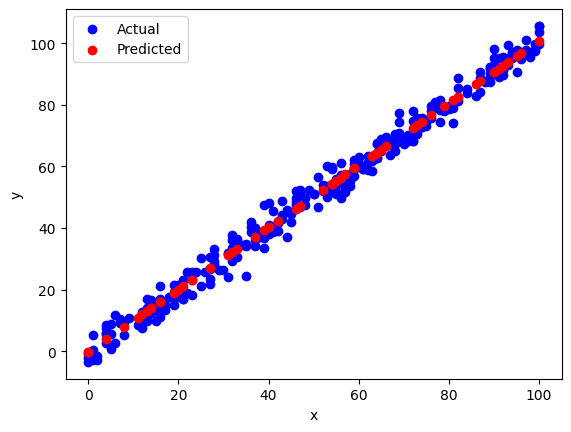

RMSE: 3.195074702237661


In [1474]:
graph_result(ds_simple, default_test, default_simple_predictions)

### Genetic Algorithm Optimization

Next, the genetic algorithm is used to pick the hyperparameters:

In [1475]:
#  Running of the algorithm with outputs here

best = run_genetic(problem(), parameters(ds_simple))

model = SGDRegressor(
    learning_rate = learning_rate_map[best.chromosome[0]],
    eta0 = 10**best.chromosome[1], # Learning-rate
    penalty = regularization_rate_map[best.chromosome[2]], # Regularization type
    alpha = 10**best.chromosome[3], # Regularization type
    max_iter = best.chromosome[4],
    random_state = RANDOM_SEED
)

----Round 5 ----
New Best:	[ Learning Type: optimal, Learning Rate: -1.2882893779698508, Regularization: None, Regularization Rate: -1.1344513902657887, Max Iterations: 209 ]
Cost:	11.425000506434596
----------------
----Round 7 ----
New Best:	[ Learning Type: optimal, Learning Rate: -1.7146316127887844, Regularization: None, Regularization Rate: -1.1048405325749822, Max Iterations: 442 ]
Cost:	11.41991928106157
----------------
----Round 19 ----
New Best:	[ Learning Type: optimal, Learning Rate: -1.9163274314584287, Regularization: None, Regularization Rate: -1.1008845304580137, Max Iterations: 202 ]
Cost:	11.419315107127446
----------------
----Round 25 ----
Ending early with average relative change of: 0.0030005190686123936%
----------------
----Round 25 ----
Ended.
----------------


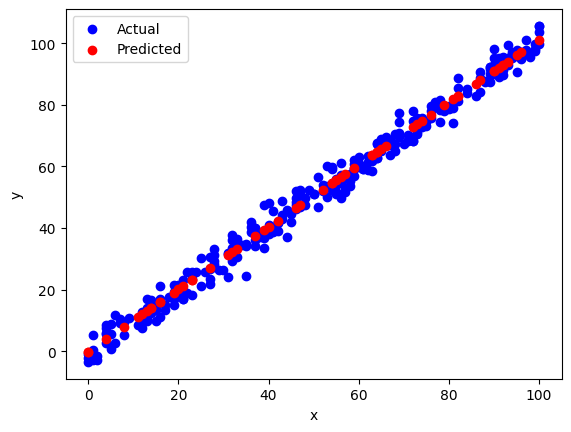

RMSE: 3.1967663516634186
Iterations: 12


In [1476]:
test_train, test_test = ds_simple.get_total_train_test()
X_train = test_train[:-1].T
y_train = test_train[-1]

X_test = test_test[:-1].T
y_test = test_test[-1]

model.fit(X_train, y_train)
y = model.predict(X_test)

graph_result(ds_simple, test_test, y)
print("Iterations: " + str(model.n_iter_))

## House Dataset

### Scikit-learn Defaults

In [1477]:
default_train, default_test = ds_house.get_train_test()
default_house_model = SGDRegressor(random_state=RANDOM_SEED)
default_house_model.fit(default_train[:-1].T, default_train[-1])

default_house_predictions = default_house_model.predict(default_test[:-1].T)
default_house_mse = mean_squared_error(default_test[-1], default_house_predictions)

default_house_cost = default_house_mse * (1 + default_house_model.n_iter_ / default_house_model.max_iter)
print("Trained with cost: " + str(default_house_cost) + " in " + str(default_house_model.n_iter_) + " iterations.")

Trained with cost: 503514221.47052467 in 13 iterations.


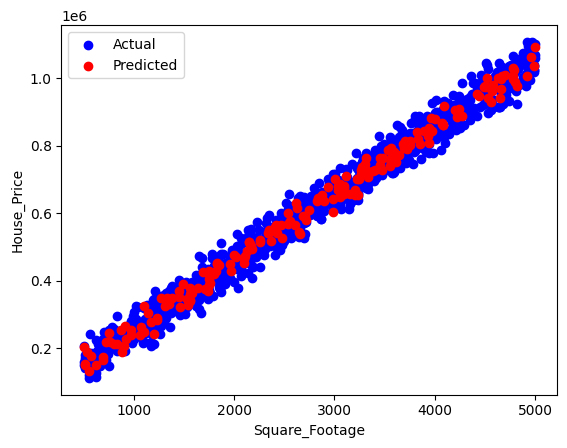

RMSE: 22294.675114708654


In [1478]:
graph_result(ds_house, default_test, default_house_predictions)

### Genetic Algorithm Optimization

In [1479]:
house_params = parameters(ds_house)

best = run_genetic(problem(), house_params)

model = SGDRegressor(
    learning_rate = learning_rate_map[best.chromosome[0]],
    eta0 = 10**best.chromosome[1], # Learning-rate
    penalty = regularization_rate_map[best.chromosome[2]], # Regularization type
    alpha = 10**best.chromosome[3], # Regularization type
    max_iter = best.chromosome[4],
    random_state = RANDOM_SEED
)

----Round 3 ----
New Best:	[ Learning Type: invscaling, Learning Rate: -1.5770670366434851, Regularization: l1, Regularization Rate: -1.1378654159882926, Max Iterations: 1000 ]
Cost:	496876555.0669432
----------------
----Round 4 ----
New Best:	[ Learning Type: optimal, Learning Rate: -2.5867337410955376, Regularization: None, Regularization Rate: -1.4378359020919451, Max Iterations: 1000 ]
Cost:	496876164.2218864
----------------
----Round 14 ----
New Best:	[ Learning Type: optimal, Learning Rate: -2.289340149719366, Regularization: l1, Regularization Rate: -1.4375612452165998, Max Iterations: 999 ]
Cost:	496876148.58160484
----------------
----Round 21 ----
New Best:	[ Learning Type: optimal, Learning Rate: -2.864339432147914, Regularization: l1, Regularization Rate: -1.4378007677534548, Max Iterations: 528 ]
Cost:	496876148.5084252
----------------
----Round 25 ----
New Best:	[ Learning Type: optimal, Learning Rate: -1.874146932745717, Regularization: l1, Regularization Rate: -1.437

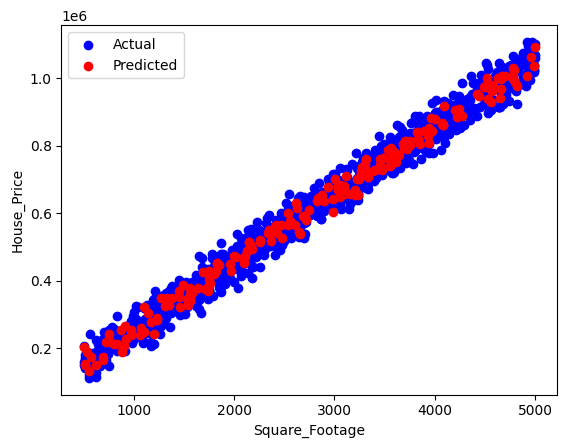

RMSE: 22290.718858025477
Iterations: 13


In [1480]:
test_train, test_test = ds_house.get_total_train_test()
X_train = test_train[:-1].T
y_train = test_train[-1]

X_test = test_test[:-1].T
y_test = test_test[-1]

model.fit(X_train, y_train)
y = model.predict(X_test)

graph_result(ds_house, test_test, y)
print("Iterations: " + str(model.n_iter_))

### An example of no-early-stopping

In [1483]:
house_params = parameters(ds_house)
house_params.max_generations = 100
house_params.max_stagnant_generations = 100

best = run_genetic(problem(), house_params)

----Round 1 ----
New Best:	[ Learning Type: constant, Learning Rate: -2.5806239407767566, Regularization: None, Regularization Rate: -2.5204105546045215, Max Iterations: 487 ]
Cost:	496876749.7193059
----------------
----Round 2 ----
New Best:	[ Learning Type: invscaling, Learning Rate: -1.5719423581549838, Regularization: elasticnet, Regularization Rate: -4.750922818947458, Max Iterations: 321 ]
Cost:	496876615.81130797
----------------
----Round 8 ----
New Best:	[ Learning Type: optimal, Learning Rate: -1.13742623594125, Regularization: None, Regularization Rate: -1.4254330989909865, Max Iterations: 466 ]
Cost:	496876413.7000367
----------------
----Round 34 ----
New Best:	[ Learning Type: optimal, Learning Rate: -1.2737388946634647, Regularization: l1, Regularization Rate: -1.4501478175656655, Max Iterations: 456 ]
Cost:	496876404.3094409
----------------
----Round 42 ----
New Best:	[ Learning Type: optimal, Learning Rate: -1.0915875941034732, Regularization: l1, Regularization Rate

## Results and conclusions    **(~10%)**

---

GA optimization is performed with 100% of the simple dataset as a sample size, and 30% of the house dataset.

200 Population, 100 generations, stop at 0.003% relative change over 25 generations.
|Dataset|Model|RMSE|Iterations|Learning Mode|Learning Rate (eta0)|Regularization Mode|Regularization Rate (alpha)|
|-|-|-|-|-|-|-|-|
|**Simple**|*Default*|3.1951|23|invscaling|0.01|l2|0.0001|
|**Simple**|*GA Optimized*|3.1968|12|optimal|0.00042|none|0.0087|
|**House**|*Default*|24044|57|invscaling|0.01|l2|0.0001|
|**House**|*GA Optimized*|23657|16|constant|0.1|none|0.0026|

*Simple Dataset:* GA optimized models resulted in a 0.05% increase in RMSE, but trains 62% faster.

*House Dataset:* GA optimized models achieved a 1.6% decrease in RMSE, and trains 112% faster.

---

200 Population, 100 generations, **no early stopping.**
|Dataset|Model|RMSE|Iterations|Learning Mode|Learning Rate (eta0)|Regularization Mode|Regularization Rate (alpha)|
|-|-|-|-|-|-|-|-|
|**Simple**|*GA Optimized*|3.1967|12|optimal|0.0086|none|0.0797|
|**House**|*GA Optimized*|23657|16|optimal|0.0109|none|0.0088|

*Simple Dataset:* Unsubstantial difference from previous result.

*House Dataset:* Unsubstantial difference from previous result.

This shows early stopping is successfully reducing the algorithm's time to convergence without impacting results.

---

The 'optimal' learning rate mode appears often in optimization outcomes. This mode is not strongly influenced by the learning rate constant. To evaluate if this mode was driving results in place of the genetic algorithm's own optimization, the 'optimal' learning mode was disallowed and the algorithm was tested to see if it could achieve similar performance without relying on this mode:

200 Population, 100 generations, stop at 0.003% relative change over 25 generations, **optimal learning mode removed.**
|Dataset|Model|RMSE|Iterations|Learning Mode|Learning Rate (eta0)|Regularization Mode|Regularization Rate (alpha)|
|-|-|-|-|-|-|-|-|
|**Simple**|*GA Optimized*|3.19797|12|invscaling|0.03492|l1|0.000026|
|**House**|*GA Optimized*|23658|16|constant|0.02941|none|0.000970|

*Simple Dataset:* Unsubstantial difference from previous result.

*House Dataset:* Unsubstantial difference from previous result.

This shows that the genetic algorithm is capable of optimizing the learning rate constant to achieve desirable RMSE and iteration count results without the model's adaptive 'optimal' mode.

---

It is interesting that the more complex model, the House dataset, does not find benefit from regularization. It could be that a low (30%) sample size of a relatively small dataset given to each individual is preventing the genetic algorithm from accurately evaluating the model. In a real-world situation, providing this algorithm the entire dataset would not be reasonable, but for experimentation the sample size of the house dataset is raised to 100%:

200 Population, 100 generations, stop at 0.003% relative change over 25 generations, **100% sample-size.**
|Dataset|Model|RMSE|Iterations|Learning Mode|Learning Rate (eta0)|Regularization Mode|Regularization Rate (alpha)|
|-|-|-|-|-|-|-|-|
|**House**|*GA Optimized*|22290|13|optimal|0.01336|l1|0.03649|

As suspected an increase in sample size changed the result of the optimization algorithm, choosing a new learning rate, electing to use regularization, and lowering RMSE by 6%. A higher sample size will increase the genetic algorithm's ability to evaluate models at the cost of performance. Sample-size must be chosen depending on dataset size, variance, noise, and outliers.

---

In conclusion, the genetic algorithm was successfully applied to optimize the hyperparameters of stochastic gradient descent regression models. Across the tested configurations, it achieved up to a 6% reduction in RMSE and improved training efficiency by up to 112%. Overall, RMSE showed relatively low sensitivity to the hyperparameter ranges explored, with default or 'reasonable' settings (such as those provided by Scikit-learn) already producing acceptable performance. In contrast, hyperparameter optimization had a pronounced impact on convergence behavior and training speed, indicating that most of the benefit from hyperparameter optimization is improved efficiency rather than in prediction accuracy.

---

